Dataset loaded successfully!

FIRST 5 RECORDS
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

LAST 5 RECORDS
        TV  Radio  Newspaper  Sales
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

DATASET SHAPE
Number of rows   : 200
Number of columns: 4

DATA TYPES
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

MISSING VALUES
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

DUPLICATE RECORDS
Number of duplicate records: 0

SUMMARY STATISTICS
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.84680

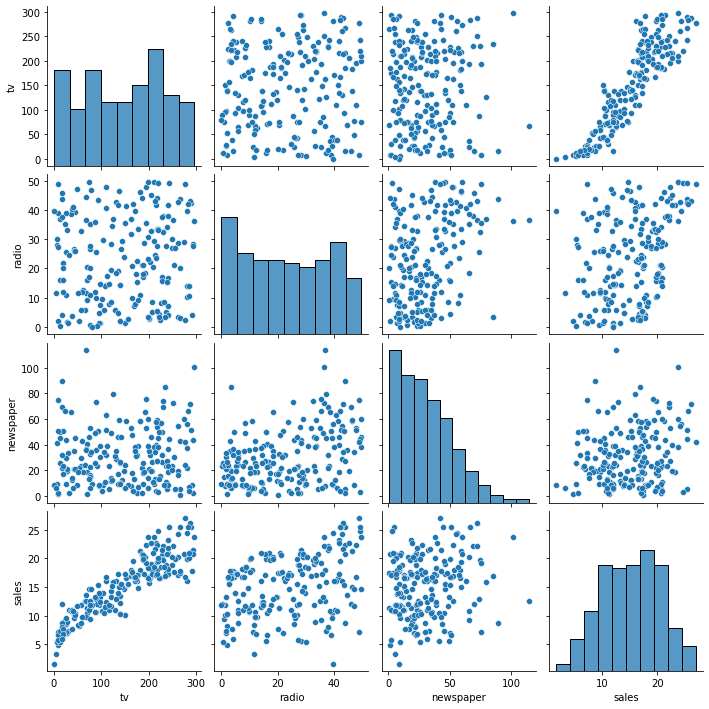


CORRELATION MATRIX
                 tv     radio  newspaper     sales
tv         1.000000  0.054809   0.056648  0.901208
radio      0.054809  1.000000   0.354104  0.349631
newspaper  0.056648  0.354104   1.000000  0.157960
sales      0.901208  0.349631   0.157960  1.000000


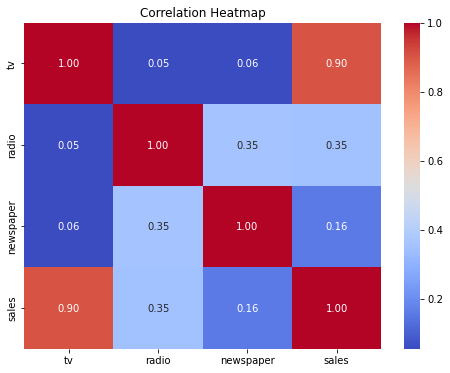


FEATURE MOST CORRELATED WITH SALES
Most strongly correlated feature: TV
Correlation value: 0.9012


In [1]:
# ============================================================
# EX3b: MODEL PLANNING AND BUILDING - REGRESSION
# Advertising Sales Prediction
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 2. LOAD DATASET
# ------------------------------------------------------------

file_path = r"Downloads\Advertising.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")


# ------------------------------------------------------------
# 3. DISPLAY FIRST 5 RECORDS
# ------------------------------------------------------------

print("\n========================================")
print("FIRST 5 RECORDS")
print("========================================")

print(df.head())


# ------------------------------------------------------------
# 4. DISPLAY LAST 5 RECORDS
# ------------------------------------------------------------

print("\n========================================")
print("LAST 5 RECORDS")
print("========================================")

print(df.tail())


# ------------------------------------------------------------
# 5. CHECK DATASET SHAPE
# ------------------------------------------------------------

print("\n========================================")
print("DATASET SHAPE")
print("========================================")

print("Number of rows   :", df.shape[0])
print("Number of columns:", df.shape[1])


# ------------------------------------------------------------
# 6. CHECK DATA TYPES
# ------------------------------------------------------------

print("\n========================================")
print("DATA TYPES")
print("========================================")

print(df.dtypes)


# ------------------------------------------------------------
# 7. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n========================================")
print("MISSING VALUES")
print("========================================")

print(df.isnull().sum())


# ------------------------------------------------------------
# 8. CHECK DUPLICATE RECORDS
# ------------------------------------------------------------

print("\n========================================")
print("DUPLICATE RECORDS")
print("========================================")

print("Number of duplicate records:", df.duplicated().sum())


# ------------------------------------------------------------
# 9. SUMMARY STATISTICS
# ------------------------------------------------------------

print("\n========================================")
print("SUMMARY STATISTICS")
print("========================================")

print(df.describe())


# ------------------------------------------------------------
# 10. CLEAN COLUMN NAMES
# ------------------------------------------------------------

# Convert all column names into lowercase.
# This makes the program work even if CSV contains
# TV, Radio, Newspaper, Sales
# or tv, radio, newspaper, sales.

df.columns = df.columns.str.strip().str.lower()

print("\nColumn Names:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 11. REMOVE UNNECESSARY INDEX COLUMN IF PRESENT
# ------------------------------------------------------------

# Some Advertising datasets contain an unnamed index column.

unnamed_columns = [
    col for col in df.columns
    if "unnamed" in col
]

if len(unnamed_columns) > 0:
    df = df.drop(columns=unnamed_columns)


# ------------------------------------------------------------
# 12. SELECT INPUT FEATURES AND TARGET
# ------------------------------------------------------------

X = df[
    [
        "tv",
        "radio",
        "newspaper"
    ]
]

y = df["sales"]

print("\nInput Features:")
print(X.head())

print("\nTarget:")
print(y.head())


# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================


# ------------------------------------------------------------
# 13. PAIR PLOT
# ------------------------------------------------------------

print("\nGenerating Pair Plot...")

sns.pairplot(
    df[
        [
            "tv",
            "radio",
            "newspaper",
            "sales"
        ]
    ]
)

plt.show()


# ------------------------------------------------------------
# 14. CORRELATION MATRIX
# ------------------------------------------------------------

correlation = df[
    [
        "tv",
        "radio",
        "newspaper",
        "sales"
    ]
].corr()

print("\n========================================")
print("CORRELATION MATRIX")
print("========================================")

print(correlation)


# ------------------------------------------------------------
# 15. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()


# ------------------------------------------------------------
# 16. FEATURE MOST STRONGLY CORRELATED WITH SALES
# ------------------------------------------------------------

sales_correlation = correlation[
    "sales"
].drop(
    "sales"
)

strongest_feature = sales_correlation.abs().idxmax()

strongest_value = sales_correlation[
    strongest_feature
]

print("\n========================================")
print("FEATURE MOST CORRELATED WITH SALES")
print("========================================")

print(
    "Most strongly correlated feature:",
    strongest_feature.upper()
)

print(
    "Correlation value:",
    round(strongest_value, 4)
)


# ============================================================
# MODEL PLANNING AND BUILDING
# ============================================================


# ------------------------------------------------------------
# 17. TRAIN-TEST SPLIT
# ------------------------------------------------------------

# 80% Training
# 20% Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
